# Bibliotekos

In [1]:
library(here)
library(tidyverse)
library(plotly)
library(patchwork)
library(zoo)
library(stats)
library(slider)
library(lubridate)
library(scales)

Warning message:
"package 'here' was built under R version 4.5.3"
here() starts at C:/Users/crist/Documents/VU, Data Science/6 semestras/Duomenu mokslo projektas/GIT/Duomenu_mokslo_projektas

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'plotly' was built under R version 4.5.3"

Attaching package: 'plotly'


The following object is masked from 'package:ggplot2':

    last_plot


The following object is masked from 'package:stats':

    filter


The following object is masked from 'package:g

# Duomenys

In [ ]:
data <- read.csv(here("code", "python",
                      "datasets_prep", "dm_project_dataset_alpha.csv"))

data <- data |> mutate(time = ymd(time))

In [3]:
str(data)
head(data)

'data.frame':	2772 obs. of  31 variables:
 $ time                                   : Date, format: "2018-07-01" "2018-07-02" ...
 $ airTemperature                         : num  11.3 10.9 13.4 13.6 16.3 ...
 $ seaLevelPressure                       : num  1011 1007 1008 1009 1008 ...
 $ relativeHumidity                       : num  72.8 94 90 88.3 70.2 ...
 $ xgb_precipitation                      : num  9.10 1.19e+01 1.00e+01 1.39e+01 2.22e-16 ...
 $ xgb_cloudCover                         : num  89.4 91.5 89.4 88.3 66 ...
 $ feelsLikeTemperature_fixed             : num  10.9 10.4 13.4 13.6 16.3 ...
 $ windSpeed_fixed                        : num  3.76 2.52 2.54 2.36 1.28 ...
 $ windGust_fixed                         : num  13.9 7 8.3 8.7 6.1 10.4 9.7 10.5 9.7 6.2 ...
 $ windDirection_fixed                    : num  356 327 271 288 293 275 292 315 294 5 ...
 $ absorbing_aerosol_index                : num  -0.78 -0.807 -0.621 -0.659 -1.01 ...
 $ NO2_column_number_density              :

,time,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,⋯,O3_Error,dust,sia,pm2p5,pans,nmvoc,nh3,pm10,tp,t2m
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-07-01,11.29583,1010.638,72.79167,9.100000e+00,89.37500,10.93333,3.762500,13.9,356,⋯,0.8230156,0.01145233,0.4123398,1.127883,1.174715,2.292138,0.1059741,1.338105,14.6533580000,12.97028
2,2018-07-02,10.86667,1006.663,94.00000,1.190000e+01,91.50000,10.42917,2.516667,7.0,327,⋯,0.7565302,0.01151537,0.9462600,1.609913,1.935448,3.792921,0.1984277,1.752331,6.4759570000,14.77985
3,2018-07-03,13.38750,1008.454,90.04167,1.000000e+01,89.37500,13.38750,2.537500,8.3,271,⋯,1.6245888,0.04419387,0.6769881,1.534471,1.787800,2.332084,0.1188589,1.789138,9.6073170000,15.96597
4,2018-07-04,13.59167,1009.237,88.29167,1.390000e+01,88.33333,13.59167,2.358333,8.7,288,⋯,0.7592764,0.12872760,0.8331606,3.229130,1.201320,2.113538,0.3611570,4.323638,0.0133075710,18.01572
5,2018-07-05,16.29167,1008.079,70.20833,2.220446e-16,66.00000,16.29167,1.283333,6.1,293,⋯,0.8920967,0.09764995,0.7374821,2.768797,1.206750,2.267631,0.3165334,3.718909,-0.0007406473,19.04031
6,2018-07-06,17.68750,1008.171,68.16667,2.220446e-16,51.33333,17.68750,3.108333,10.4,275,⋯,0.8659980,0.05807160,0.9012731,2.499407,1.360830,2.769363,0.1619993,3.054053,0.8568160500,19.61520


# Sezoniškumas

## Ar tarša pasižymi sezoniškumu?

### NO2_column_number_density

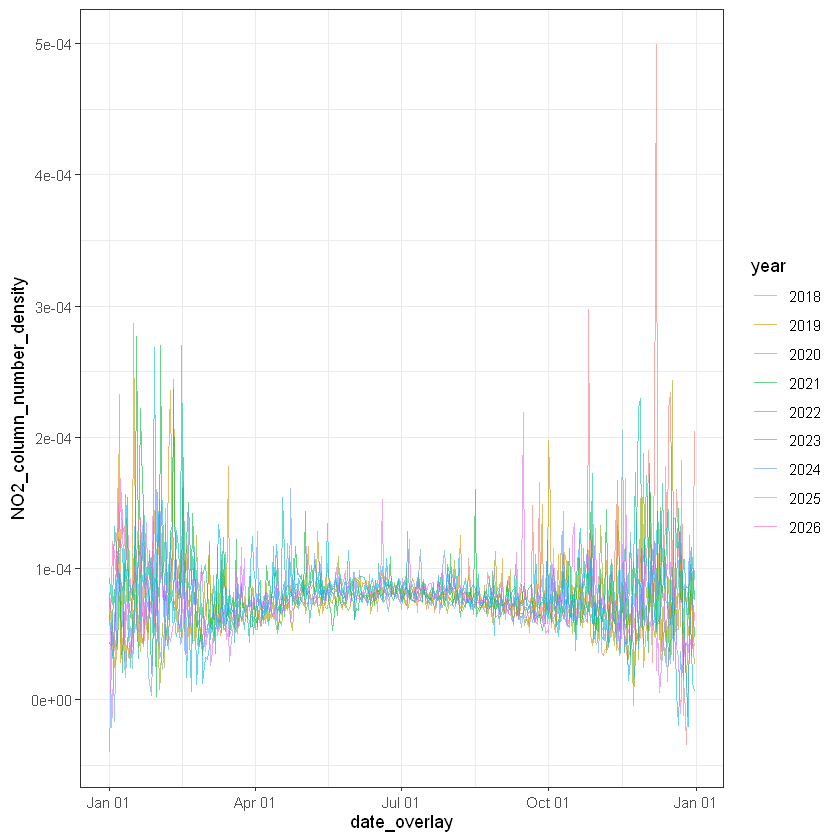

In [5]:
p_NO2_dens <- data |>
  mutate(
    date_overlay = update(time, year = 2000),
    year = factor(year(time))
  ) |>
  ggplot(aes(x = date_overlay, y = NO2_column_number_density, color = year)) +
  geom_line(alpha = 0.6) +
  theme_bw() +
  scale_x_date(date_labels = "%b %d")

p_NO2_dens
# ggplotly(p_NO2_dens)

In [10]:
offset_val <- max(data$NO2_column_number_density, na.rm = TRUE) * 0.4

plot_data <- data |> 
  mutate(
    date_overlay = update(time, year = 2000),
    year = factor(year(time)),
    year_index = as.numeric(year) - 1,
    vertical_shift = year_index * offset_val
)

avg_seasonal <- data |>
  mutate(date_overlay = update(time, year = 2000)) |>
  group_by(date_overlay) |>
  summarize(mean_no2 = mean(NO2_column_number_density, na.rm = TRUE))

background_data <- expand_grid(
  avg_seasonal, 
  year = unique(plot_data$year)
) |>
  mutate(
    year_index = as.numeric(year) - 1,
    vertical_shift = year_index * offset_val
  )

p_NO2_dens_top <- ggplot() +
  geom_line(data = background_data, 
            aes(x = date_overlay, y = mean_no2 + vertical_shift, group = year), 
            color = "grey70", linewidth = .9) +
  geom_line(data = plot_data, 
            aes(x = date_overlay, y = NO2_column_number_density + vertical_shift, color = year), 
            size = 0.7) +
  scale_x_date(date_labels = "%b") +
  theme_bw() + 
  theme(
    axis.ticks.y = element_blank(),
    axis.text.y = element_blank(),
  ) +
  labs(x = "Mėnesis", y = NULL, color = "Metai")

In [11]:
p_NO2_dens_bottom <- data %>%
  mutate(
    date_overlay = update(time, year = 2000)
  ) %>%
  group_by(date_overlay) %>%
  summarize(
    mean_no2 = mean(NO2_column_number_density, na.rm = TRUE),
    sd_no2 = sd(NO2_column_number_density, na.rm = TRUE)
  ) %>%
  ggplot(aes(x = date_overlay, y = mean_no2)) +
  geom_line(color = "red", linewidth = 0.5) +
  geom_ribbon(aes(ymin = mean_no2 - sd_no2, ymax = mean_no2 + sd_no2), alpha = 0.2) +
  scale_x_date(date_labels = "%b %d") +
  theme_bw() +
  labs(title = "Vidutinis NO2 sezoniškumas", y = "NO2 Tankis", x = "Mėnesis")

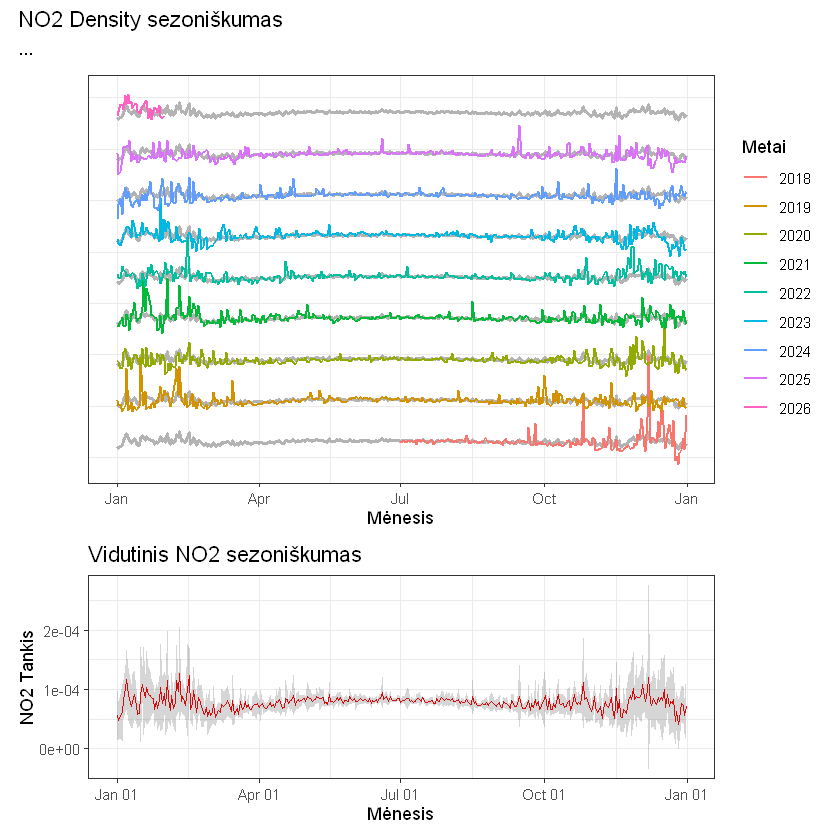

In [12]:
p_NO2_dens_top / p_NO2_dens_bottom +
  plot_layout(heights = c(2, 1)) + 
  plot_annotation(
    title = "NO2 Density sezoniškumas",
    subtitle = "..."
  )

### H2O_column_number_density

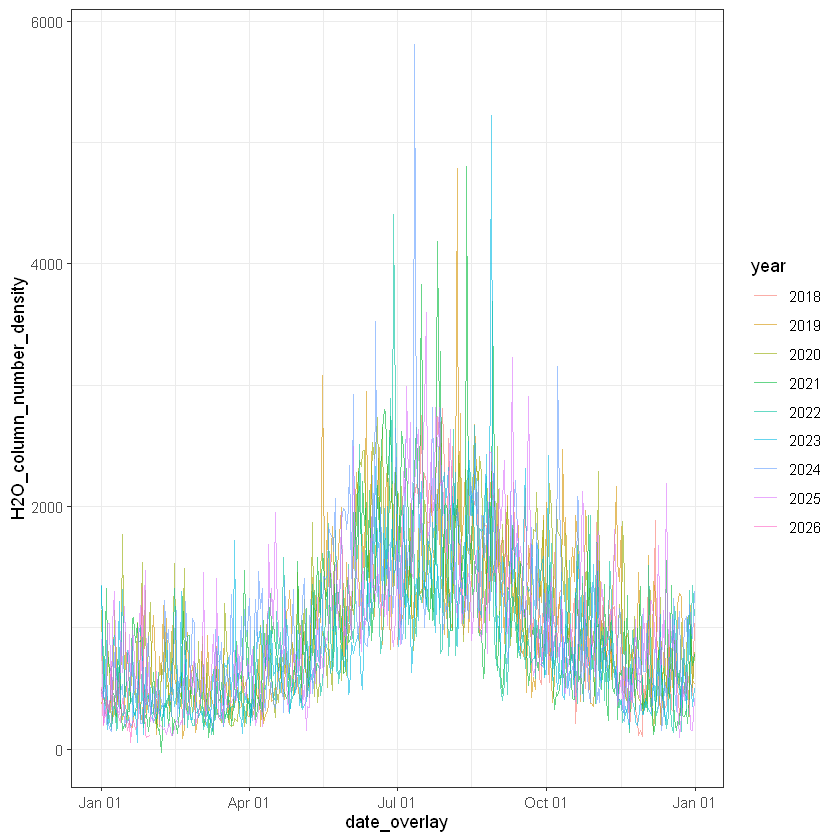

In [14]:
p_H2O_dens <- data %>% 
  mutate(
    date_overlay = update(time, year = 2000),
    year = factor(year(time))
  ) %>% 
  ggplot(aes(x = date_overlay, y = H2O_column_number_density, color = year)) +
  geom_line(alpha = 0.6) +
  theme_bw() +
  scale_x_date(date_labels = "%b %d")

p_H2O_dens
# ggplotly(p_H2O_dens)

### BrO

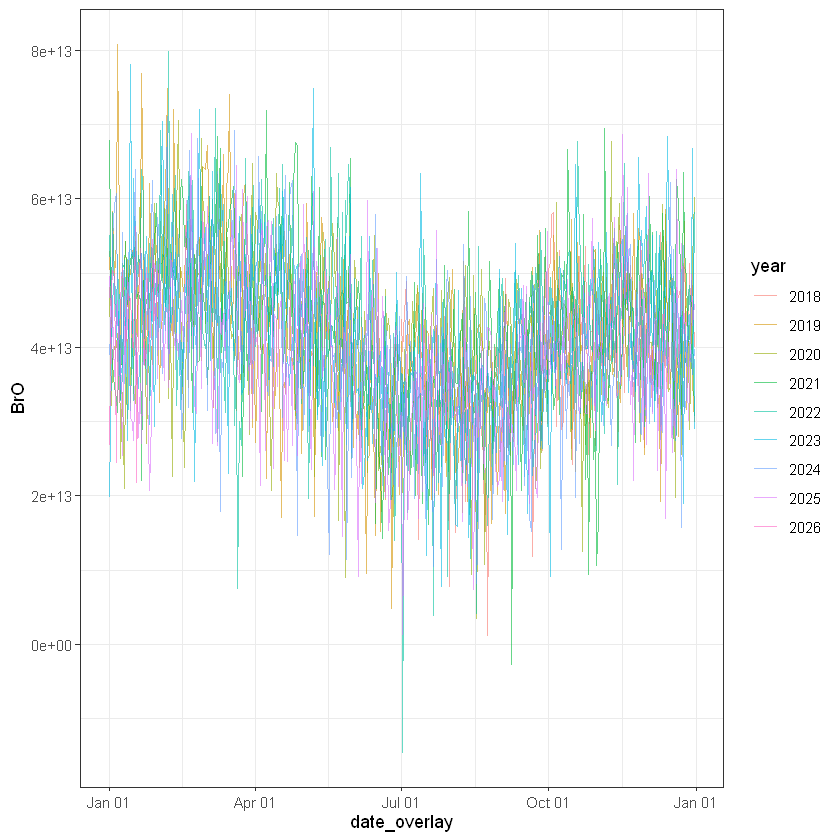

In [16]:
p_BrO <- data %>% 
  mutate(
    date_overlay = update(time, year = 2000),
    year = factor(year(time))
  ) %>% 
  ggplot(aes(x = date_overlay, y = BrO, color = year)) +
  geom_line(alpha = 0.6) +
  theme_bw() +
  scale_x_date(date_labels = "%b %d")

p_BrO
# ggplotly(p_BrO)

## Sezoniškumas pagal SD

In [17]:
season_sd_plot <- function(data, var_name) {
  var_label <- deparse(substitute(var_name))
  
  p <- data %>%
  mutate(
    date_overlay = update(time, year = 2000)
  ) %>%
  group_by(date_overlay) %>%
  summarize(
    mean_no2 = mean({{ var_name }}, na.rm = TRUE),
    sd_no2 = sd({{ var_name }}, na.rm = TRUE)
  ) %>%
  ggplot(aes(x = date_overlay, y = mean_no2)) +
  geom_line(color = "red", linewidth = 0.5) +
  geom_ribbon(aes(ymin = mean_no2 - sd_no2, ymax = mean_no2 + sd_no2), alpha = 0.2) +
  scale_x_date(date_labels = "%b %d") +
  theme_bw() +
  labs(y = var_label, x = NULL)
  
  return(p)
}

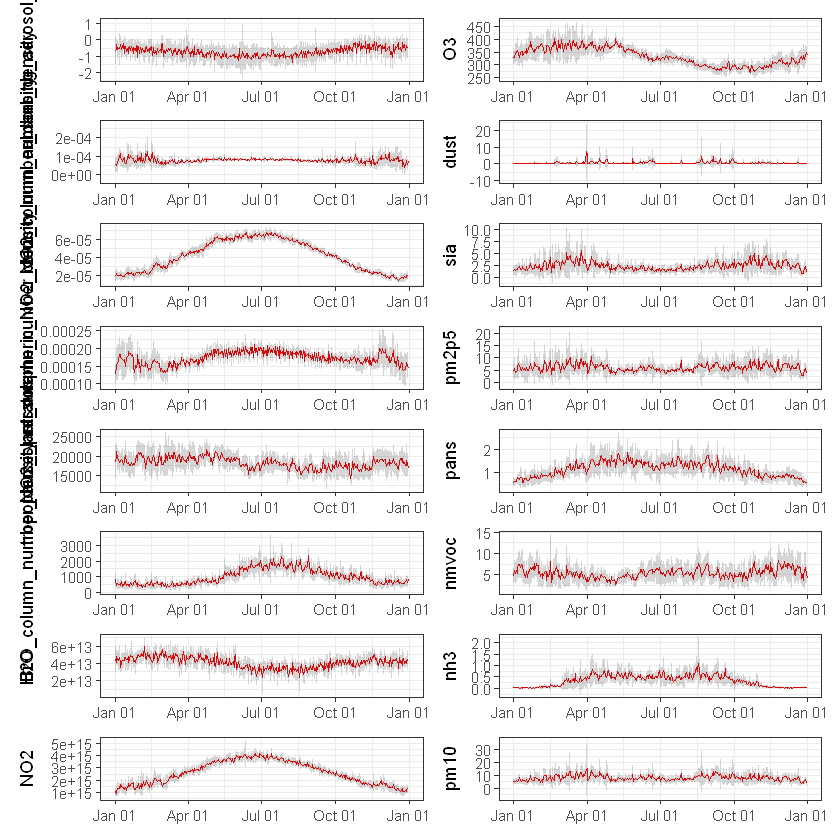

In [18]:
(season_sd_plot(data, absorbing_aerosol_index) /
season_sd_plot(data, NO2_column_number_density) /
season_sd_plot(data, stratospheric_NO2_column_number_density) /
season_sd_plot(data, NO2_slant_column_number_density) /
season_sd_plot(data, tropopause_pressure) /
season_sd_plot(data, H2O_column_number_density) /
season_sd_plot(data, BrO) /
season_sd_plot(data, NO2)) |
  
(season_sd_plot(data, O3) /
season_sd_plot(data, dust) /
season_sd_plot(data, sia) /
season_sd_plot(data, pm2p5) /
season_sd_plot(data, pans) /
season_sd_plot(data, nmvoc) /
season_sd_plot(data, nh3) /
season_sd_plot(data, pm10))

In [19]:
get_seasonal_cv <- function(data, var_name, window_size = 30) {
  
  data %>%
    mutate(doy = yday(time)) %>%
    group_by(doy) %>%
    summarize(
      mu = mean({{ var_name }}, na.rm = TRUE),
      sigma = sd({{ var_name }}, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(
      cv = ifelse(abs(mu) > 0, sigma / abs(mu), NA)
    ) %>%
    mutate(
      roll_cv = slide_dbl(cv, mean, .before = window_size, .complete = FALSE)
    ) %>%
    mutate(date_overlay = as.Date(paste0("2000-", doy), format = "%Y-%j"))
}

rolling_cv_plot <- function(data, var_name, top_name = FALSE) {
  var_label <- deparse(substitute(var_name))
  
  cv_data <- get_seasonal_cv(data, {{ var_name }}, window_size = 15)
  
  p2 <- ggplot(cv_data, aes(x = date_overlay, y = roll_cv)) +
    geom_line(color = "darkgreen", linewidth = 0.5) +
    scale_x_date(date_labels = "%b %d") +
    theme_bw() +
    labs(y = "Slenkantis CV", x = "Mėnesis") +
    theme(plot.title = element_text(size = 10))
  
  return(p2)
}

season_rolling_sd_plot <- function(data, var_name, top_name = FALSE) {
  var_label <- deparse(substitute(var_name))
  
  p1 <- data %>%
  mutate(
    date_overlay = update(time, year = 2000)
  ) %>%
  group_by(date_overlay) %>%
  summarize(
    mean_no2 = mean({{ var_name }}, na.rm = TRUE),
    sd_no2 = sd({{ var_name }}, na.rm = TRUE)
  ) %>%
  ggplot(aes(x = date_overlay, y = mean_no2)) +
  geom_line(color = "red", linewidth = 0.5) +
  geom_ribbon(aes(ymin = mean_no2 - sd_no2, ymax = mean_no2 + sd_no2), alpha = 0.2) +
  scale_x_date(date_labels = "%b %d") +
  theme_bw() +
  theme(plot.title = element_text(size = 10))
  
  if (top_name) {
    p1 <- p1 + labs(title = var_label, x = NULL, y = NULL)
  } else {
    p1 <- p1 + labs(y = var_label, x = NULL)
  }
  
  p2 <- rolling_cv_plot(data, {{ var_name }})
  
  return(p1+p2)
}

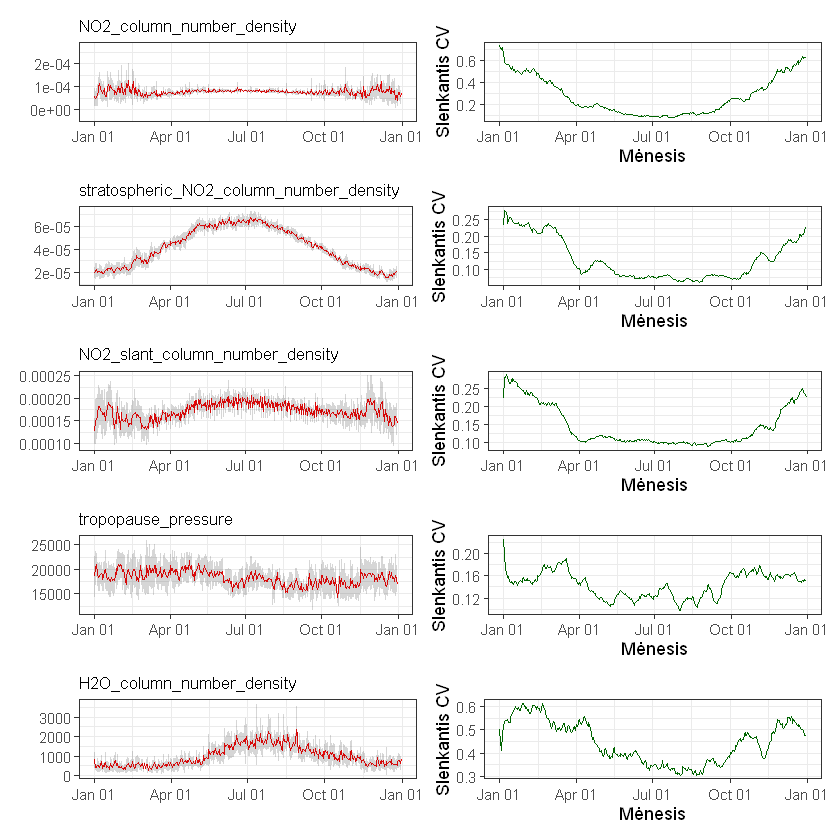

In [20]:
#season_rolling_sd_plot(data, absorbing_aerosol_index, TRUE) /
season_rolling_sd_plot(data, NO2_column_number_density, TRUE) /
season_rolling_sd_plot(data, stratospheric_NO2_column_number_density, TRUE) /
season_rolling_sd_plot(data, NO2_slant_column_number_density, TRUE) /
season_rolling_sd_plot(data, tropopause_pressure, TRUE) /
season_rolling_sd_plot(data, H2O_column_number_density, TRUE)

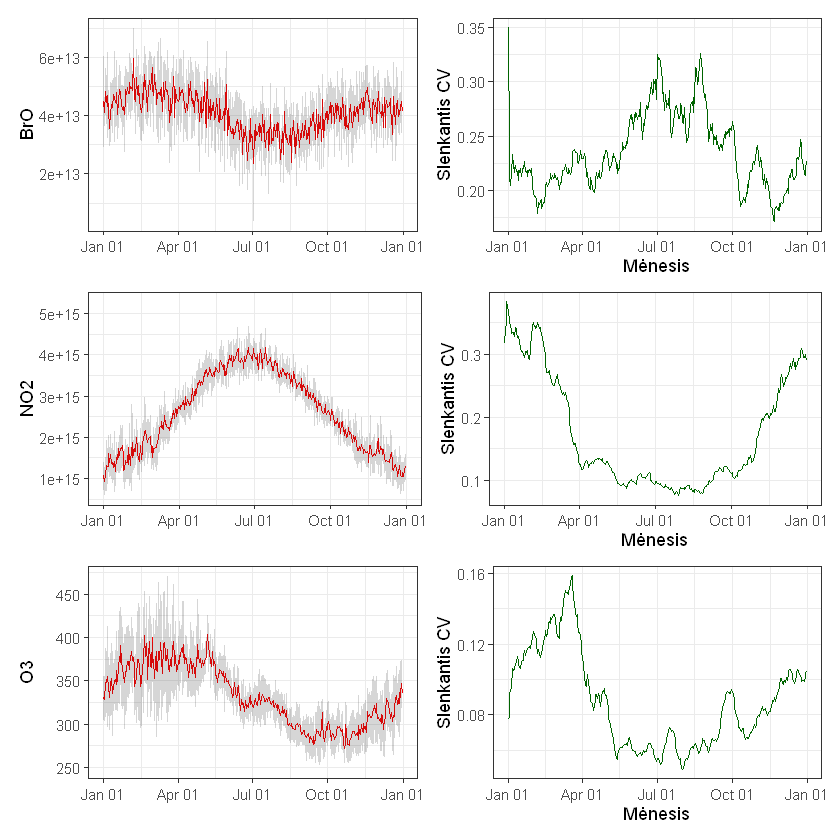

In [21]:
season_rolling_sd_plot(data, BrO) /
season_rolling_sd_plot(data, NO2) /
season_rolling_sd_plot(data, O3)

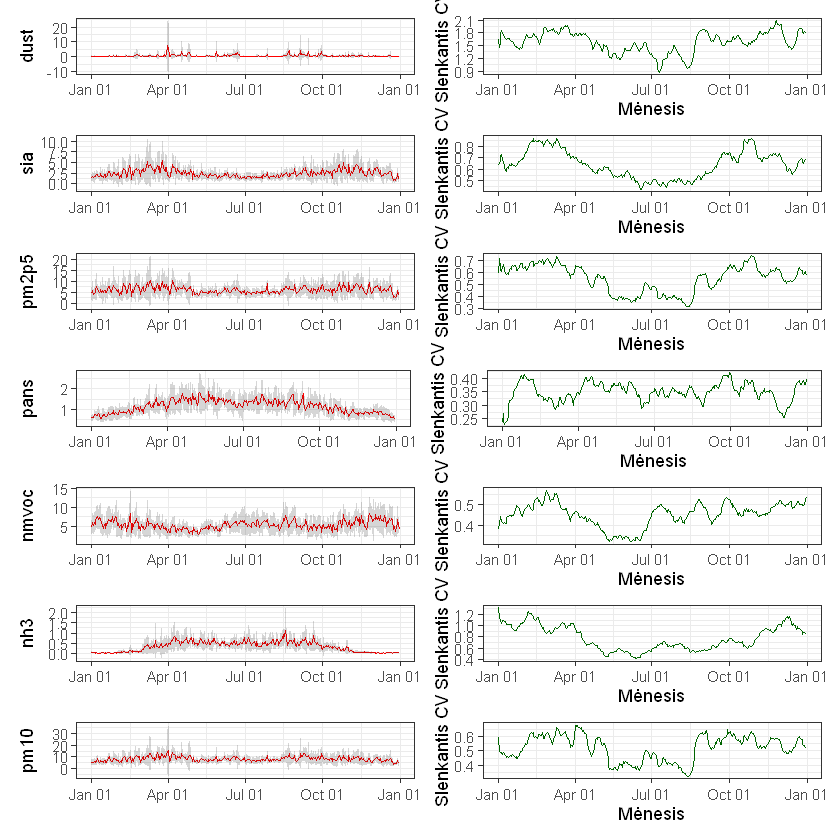

In [22]:
season_rolling_sd_plot(data, dust) /
season_rolling_sd_plot(data, sia) /
season_rolling_sd_plot(data, pm2p5) /
season_rolling_sd_plot(data, pans) /
season_rolling_sd_plot(data, nmvoc) /
season_rolling_sd_plot(data, nh3) /
season_rolling_sd_plot(data, pm10)

## Ar bent vieno MetOp rodiklio paklaida kinta ar yra pastovi?

### BrO

In [23]:
p_BrO_error <- data %>%
  ggplot(aes(x = time, y = BrO) ) +
  geom_ribbon(aes(ymin = BrO - BrO_Error, ymax = BrO + BrO_Error, fill = "Paklaida"), alpha = 0.5) +
  geom_line(aes(color = "BrO"), linewidth = 0.05, alpha = 0.9) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
  scale_y_continuous(
    labels = label_number(scale = 1e-13, accuracy = 0.1)
  ) +
  scale_fill_manual(values = c("Paklaida" = "red")) +
  scale_color_manual(values = c("BrO" = "gold")) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 9),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0) ) +
  labs(title = "BrO vidutinės mėn. paklaidos sezoniškumas",
       y = expression(BrO ~ Koncentracija ~ (10^{13}) ),
       x = NULL,
       subtitle = "Šaltuoju periodu paklaida vidutiniškai mažiausia. Didžiausia Q3 ketvirtyje.",
       fill = NULL, 
       color = NULL)

In [24]:
df_Br_plot <- data %>%
  mutate(month_group = floor_date(time, unit = "month") ) %>%
  mutate(BrO_global_mean = mean(BrO, na.rm = TRUE)) %>% 
  group_by(month_group) %>%
  mutate(
    BrO_month_avg = mean(BrO, na.rm = TRUE),
    BrO_error_month_avg = mean(BrO_Error, na.rm = TRUE),
    adjustment = BrO_global_mean - BrO_month_avg,
    BrO_centered = BrO_month_avg + adjustment
  ) %>%
  ungroup() %>%
  select(-month_group, -BrO_global_mean, -adjustment)

seasonal_summary <- data %>%
  mutate(season = quarter(time) ) %>%
  group_by(season) %>%
  summarise(
    avg_BrO = mean(BrO, na.rm = TRUE),
    avg_Error = mean(BrO_Error, na.rm = TRUE)
  ) %>%
  mutate(Br_CV = avg_Error / avg_BrO)

CV_values <- seasonal_summary$Br_CV %>% round(2)

p_BrO_error_avg <- df_Br_plot %>%
  ggplot(aes(x = time, y = BrO_centered)) +
  geom_ribbon(aes(ymin = BrO_centered - BrO_error_month_avg, ymax = BrO_centered + BrO_error_month_avg), alpha = 0.5, fill = 'gold') +
  geom_line(color = "red", linewidth = 0.1, linetype = 'dashed') +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0)) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 9),
        plot.subtitle = element_text(size = 10, face = "bold"),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank() ) +
  labs(y = "Centruota paklaida",
       x = "Metai",
       subtitle = paste("CV: Q1=", CV_values[1],
                        ", Q2=", CV_values[2],
                        ", Q3=", CV_values[3],
                        ", Q4=", CV_values[4], sep = ""))

rm(df_Br_plot)

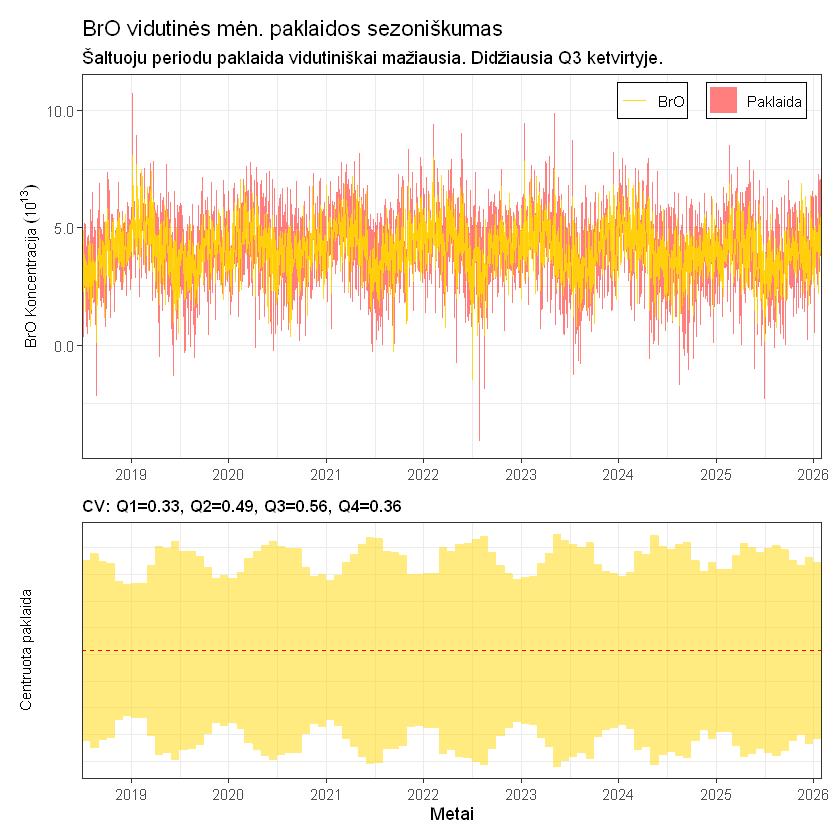

In [25]:
p_BrO_error / p_BrO_error_avg +
  plot_layout(heights = c(3, 2))

### NO2

In [26]:
p_NO2_error <- data %>%
  ggplot(aes(x = time, y = NO2) ) +
  geom_ribbon(aes(ymin = NO2 - NO2_Error, ymax = NO2 + NO2_Error, fill = "Paklaida"), alpha = 0.5) +
  geom_line(aes(color = "NO2"), linewidth = 0.05, alpha = 0.9) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
  scale_y_continuous(
    labels = label_number(scale = 1e-15, accuracy = 0.1)
  ) +
  scale_fill_manual(values = c("Paklaida" = "red")) +
  scale_color_manual(values = c("NO2" = "lightgreen")) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 9),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0)
      ) +
  labs(title = "NO2 vidutinės mėn. paklaidos sezoniškumas",
       y = expression(NO2 ~ Koncentracija ~ (10^{15}) ),
       x = NULL,
       subtitle = "NO2 paklaida pastovi (CV 11-13 %).",
       fill = NULL, 
       color = NULL)

In [27]:
df_NO2_plot <- data %>%
  mutate(month_group = floor_date(time, unit = "month") ) %>%
  mutate(NO2_global_mean = mean(NO2, na.rm = TRUE)) %>% 
  group_by(month_group) %>%
  mutate(
    NO2_month_avg = mean(NO2, na.rm = TRUE),
    NO2_error_month_avg = mean(NO2_Error, na.rm = TRUE),
    adjustment = NO2_global_mean - NO2_month_avg,
    NO2_centered = NO2_month_avg + adjustment
  ) %>%
  ungroup() %>%
  select(-month_group, -NO2_global_mean, -adjustment)

seasonal_summary <- data %>%
  mutate(season = quarter(time) ) %>%
  group_by(season) %>%
  summarise(
    avg_NO2 = mean(NO2, na.rm = TRUE),
    avg_Error = mean(NO2_Error, na.rm = TRUE)
  ) %>%
  mutate(NO2_CV = avg_Error / avg_NO2)

CV_values <- seasonal_summary$NO2_CV %>% round(2)

p_NO2_error_avg <- df_NO2_plot %>%
  ggplot(aes(x = time, y = NO2_centered)) +
  geom_ribbon(aes(ymin = NO2_centered - NO2_error_month_avg, ymax = NO2_centered + NO2_error_month_avg), alpha = 0.5, fill = 'lightgreen') +
  geom_line(color = "red", linewidth = 0.1, linetype = 'dashed') +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0)) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 9),
        plot.subtitle = element_text(size = 10, face = "bold"),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank() ) +
  labs(y = "Centruota paklaida",
       x = "Metai",
       subtitle = paste("CV: Q1=", CV_values[1],
                        ", Q2=", CV_values[2],
                        ", Q3=", CV_values[3],
                        ", Q4=", CV_values[4], sep = ""))

rm(df_NO2_plot)

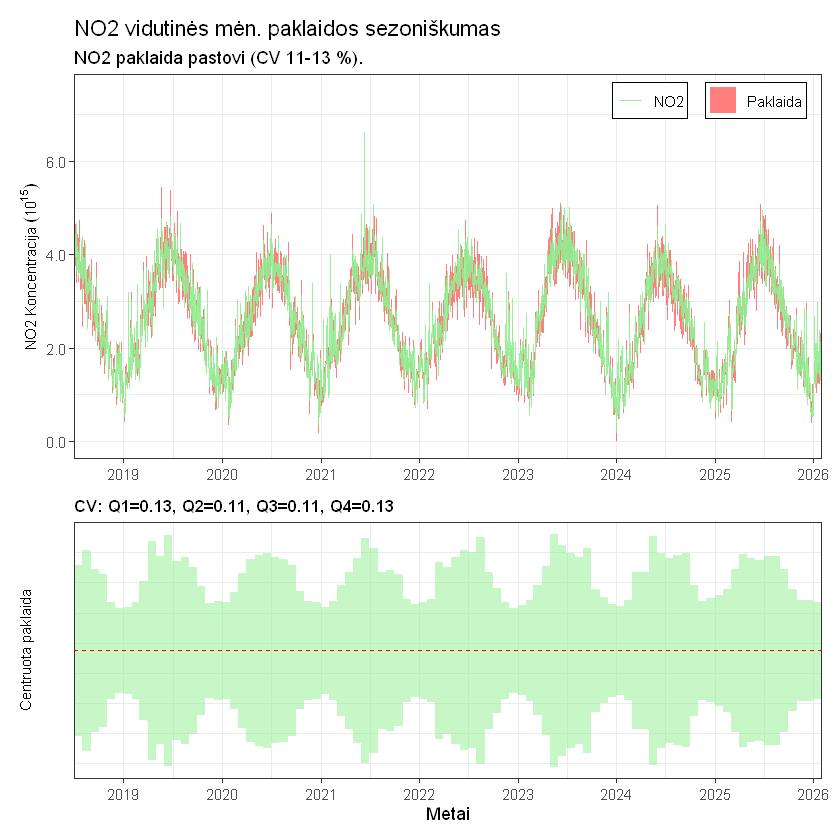

In [28]:
p_NO2_error / p_NO2_error_avg +
  plot_layout(heights = c(3, 2))

### O3

In [29]:
p_O3_error <- data %>%
  ggplot(aes(x = time, y = O3) ) +
  geom_ribbon(aes(ymin = O3 - O3_Error, ymax = O3 + O3_Error, fill = "Paklaida")) +
  geom_line(aes(color = "O3"), linewidth = 0.05, alpha = 0.6) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
  scale_fill_manual(values = c("Paklaida" = "darkblue")) +
  scale_color_manual(values = c("O3" = "lightblue")) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 9),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0) ) +
  labs(title = "O3 vidutinės mėn. paklaidos sezoniškumas",
       y = "O3 koncentracija",
       x = NULL,
       subtitle = "O3 paklaida minimali (CV < 1%).",
       fill = NULL, 
       color = NULL)

In [30]:
df_O3_plot <- data %>%
  mutate(month_group = floor_date(time, unit = "month") ) %>%
  mutate(O3_global_mean = mean(O3, na.rm = TRUE)) %>% 
  group_by(month_group) %>%
  mutate(
    O3_month_avg = mean(O3, na.rm = TRUE),
    O3_error_month_avg = mean(O3_Error, na.rm = TRUE),
    adjustment = O3_global_mean - O3_month_avg,
    O3_centered = O3_month_avg + adjustment
  ) %>%
  ungroup() %>%
  select(-month_group, -O3_global_mean, -adjustment)

seasonal_summary <- data %>%
  mutate(season = quarter(time) ) %>%
  group_by(season) %>%
  summarise(
    avg_O3 = mean(O3, na.rm = TRUE),
    avg_Error = mean(O3_Error, na.rm = TRUE)
  ) %>%
  mutate(O3_CV = avg_Error / avg_O3)

CV_values <- seasonal_summary$O3_CV %>% round(2)

p_O3_error_avg <- df_O3_plot %>%
  ggplot(aes(x = time, y = O3_centered)) +
  geom_ribbon(aes(ymin = O3_centered - O3_error_month_avg, ymax = O3_centered + O3_error_month_avg), alpha = 0.5, fill = 'lightblue') +
  geom_line(color = "red", linewidth = 0.1, linetype = 'dashed') +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0)) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 9),
        plot.subtitle = element_text(size = 10, face = "bold"),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank() ) +
  labs(y = "Centruota paklaida",
       x = "Metai",
       subtitle = paste("CV: Q1=", CV_values[1],
                        ", Q2=", CV_values[2],
                        ", Q3=", CV_values[3],
                        ", Q4=", CV_values[4], sep = ""))

rm(df_O3_plot)

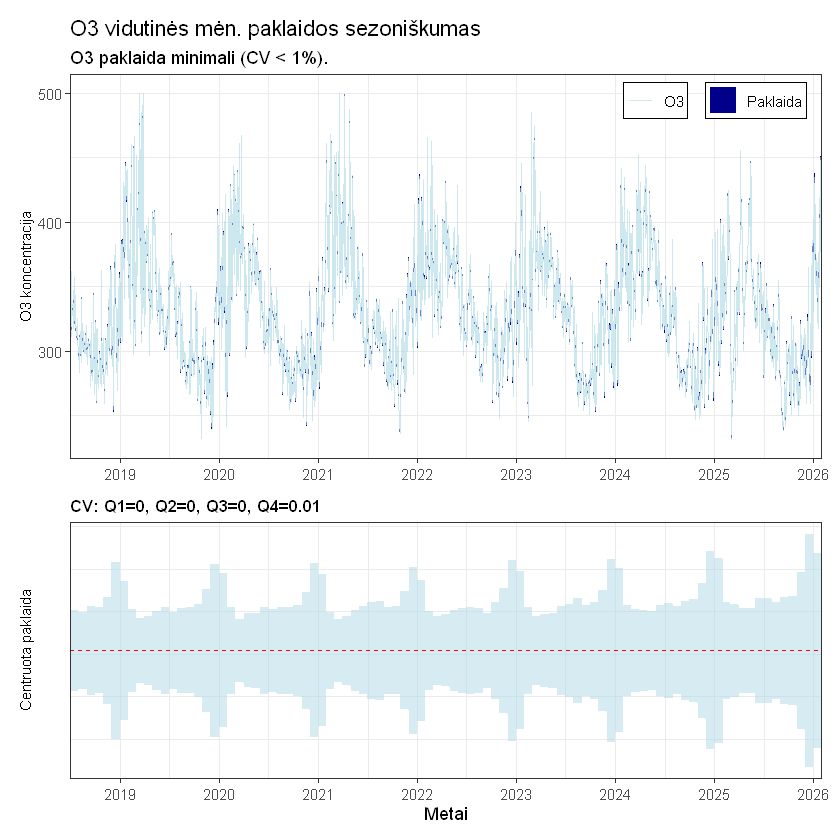

In [31]:
p_O3_error / p_O3_error_avg +
  plot_layout(heights = c(3, 2))

## Pagal ACF

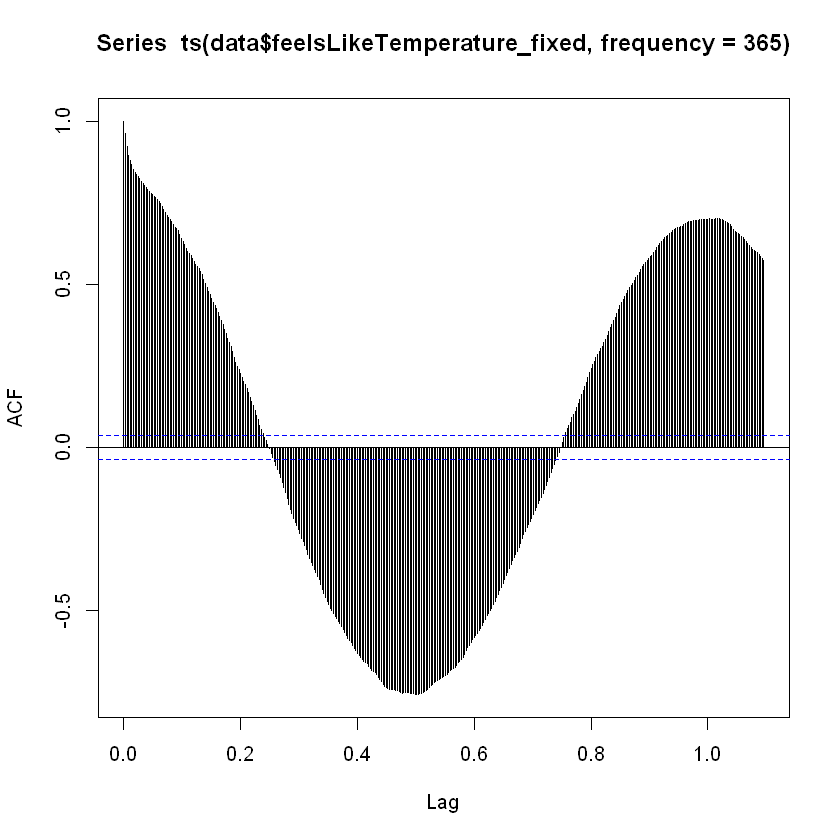

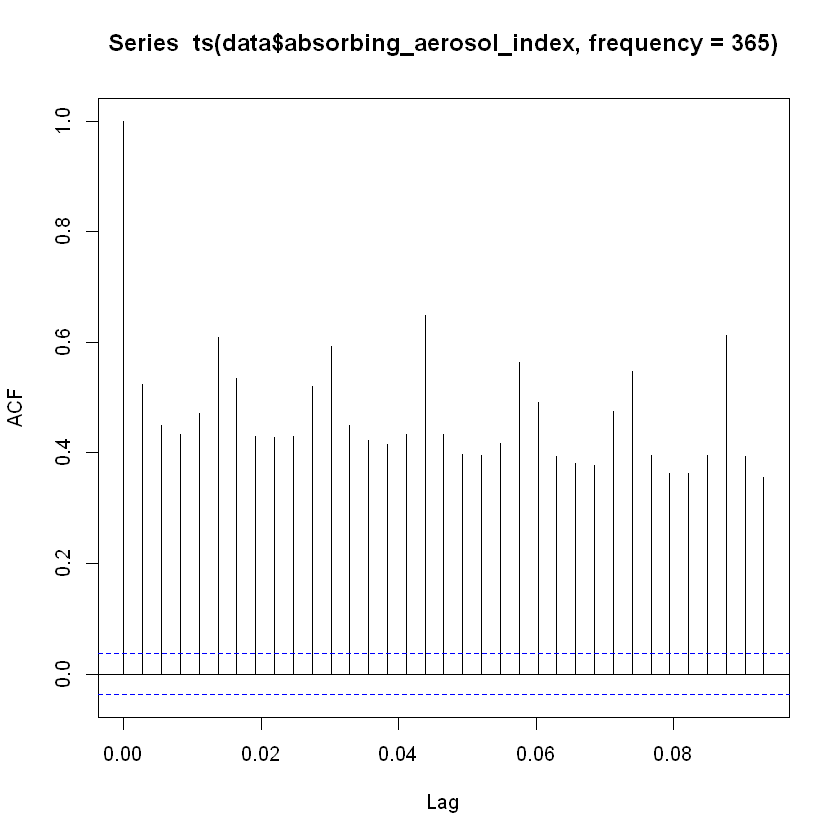

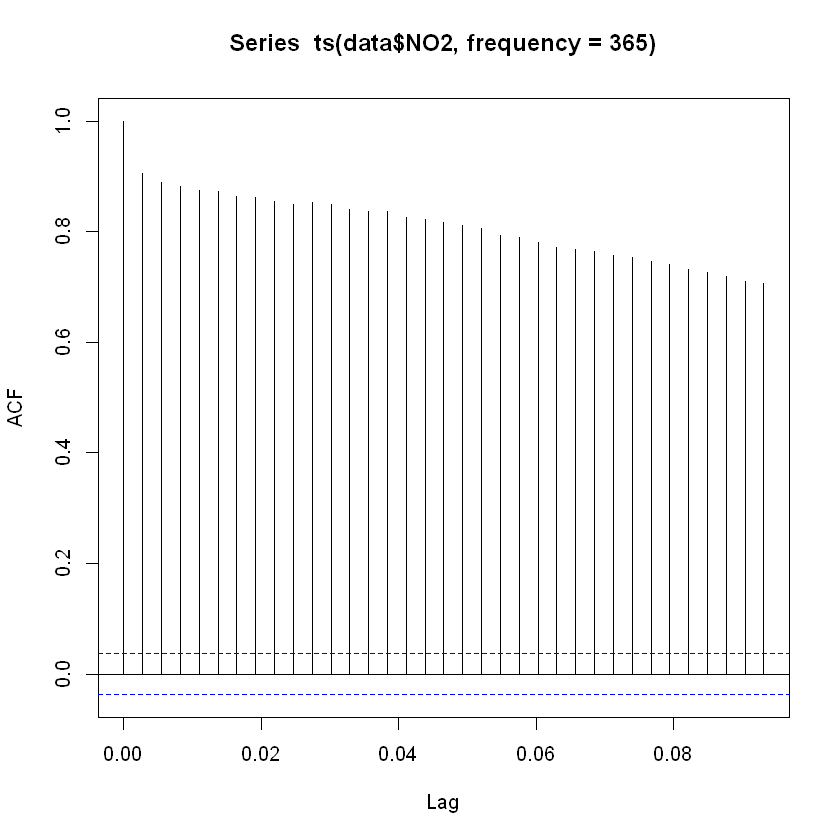

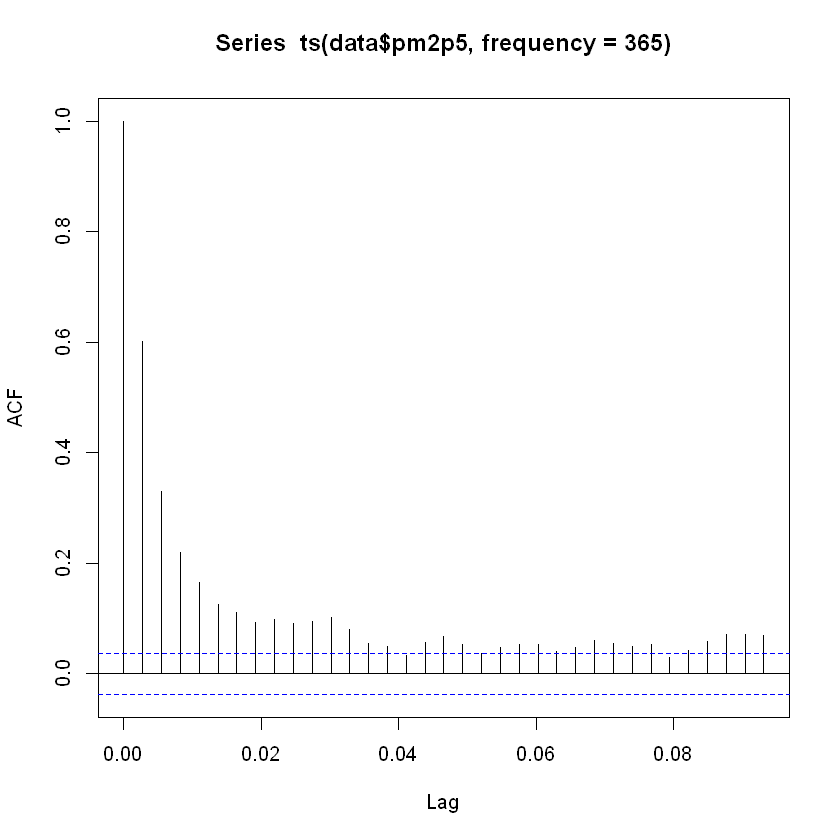

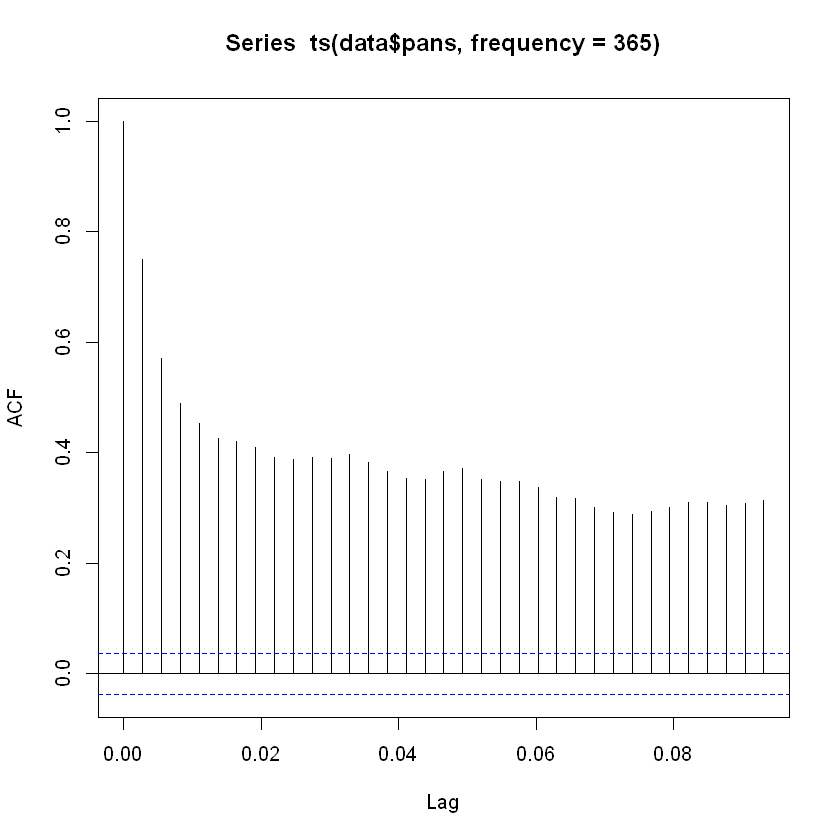

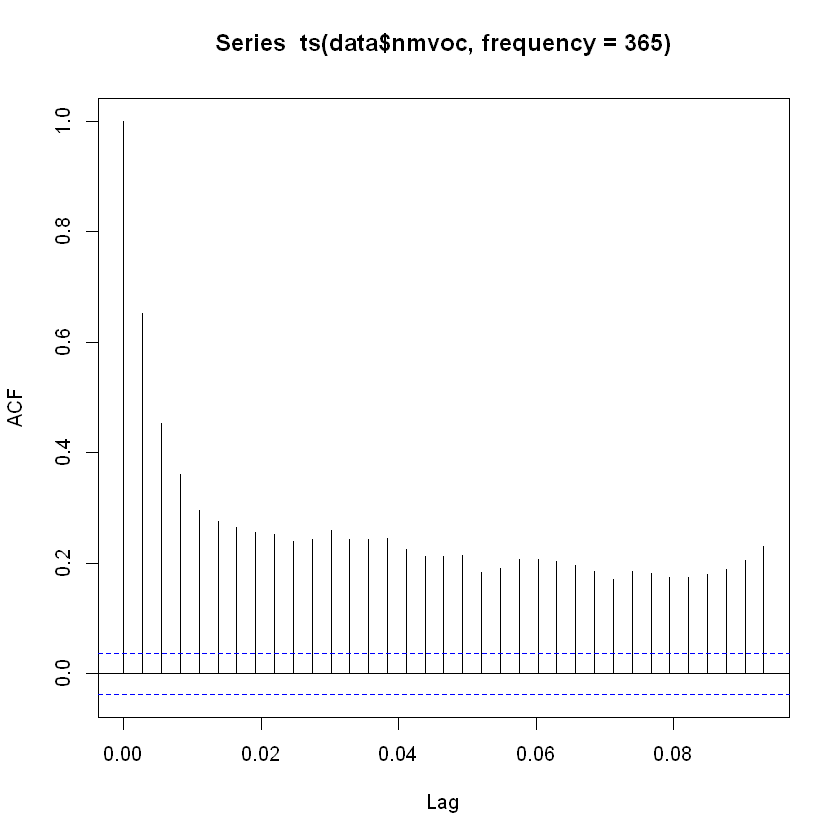

In [33]:
acf(ts(data$feelsLikeTemperature_fixed, frequency = 365), lag.max = 400)

acf(ts(data$absorbing_aerosol_index, frequency = 365))

acf(ts(data$NO2, frequency = 365))

acf(ts(data$pm2p5, frequency = 365), na.action = na.omit)

acf(ts(data$pans, frequency = 365), na.action = na.omit)

acf(ts(data$nmvoc, frequency = 365), na.action = na.omit)

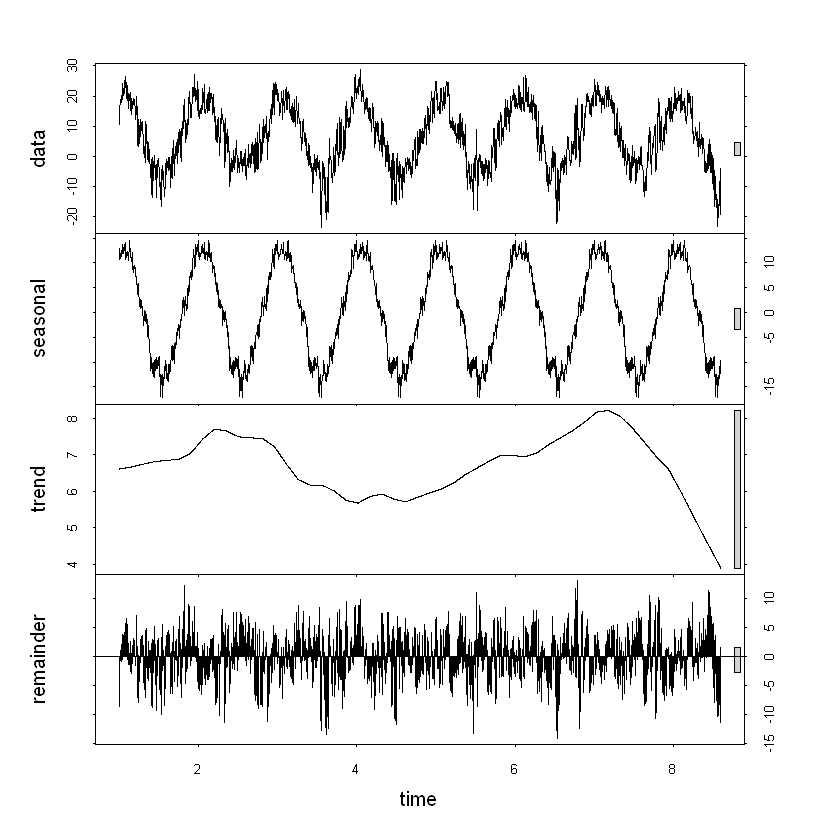

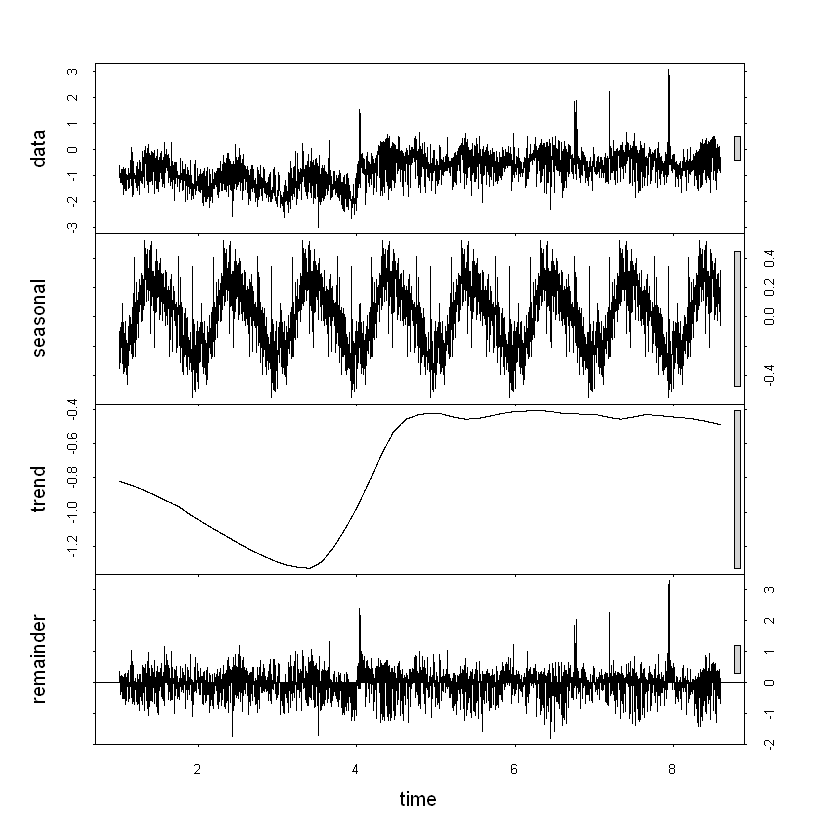

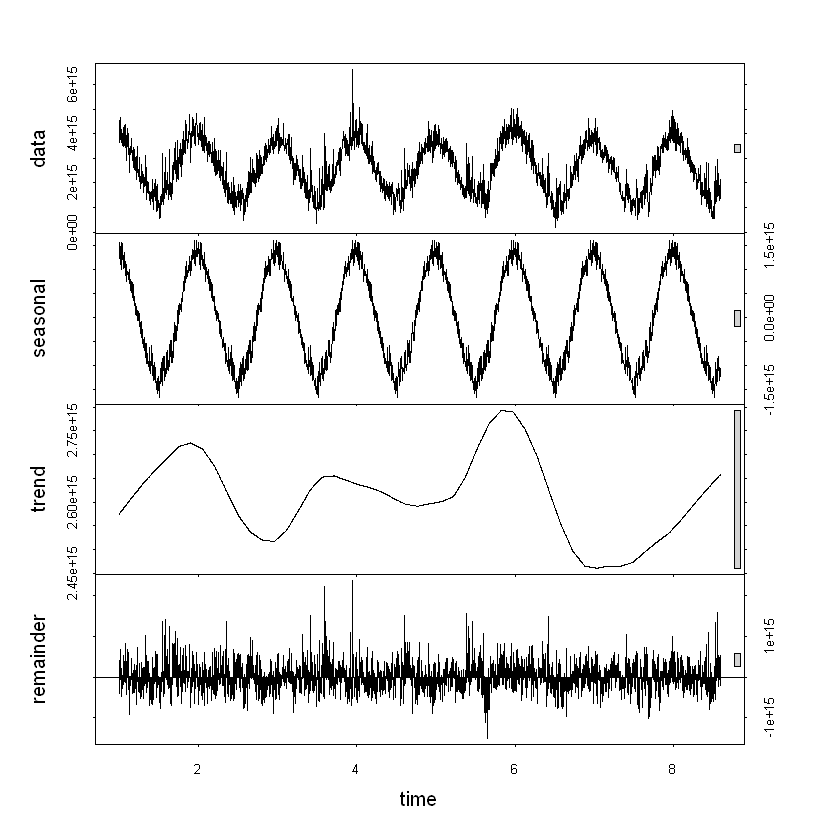

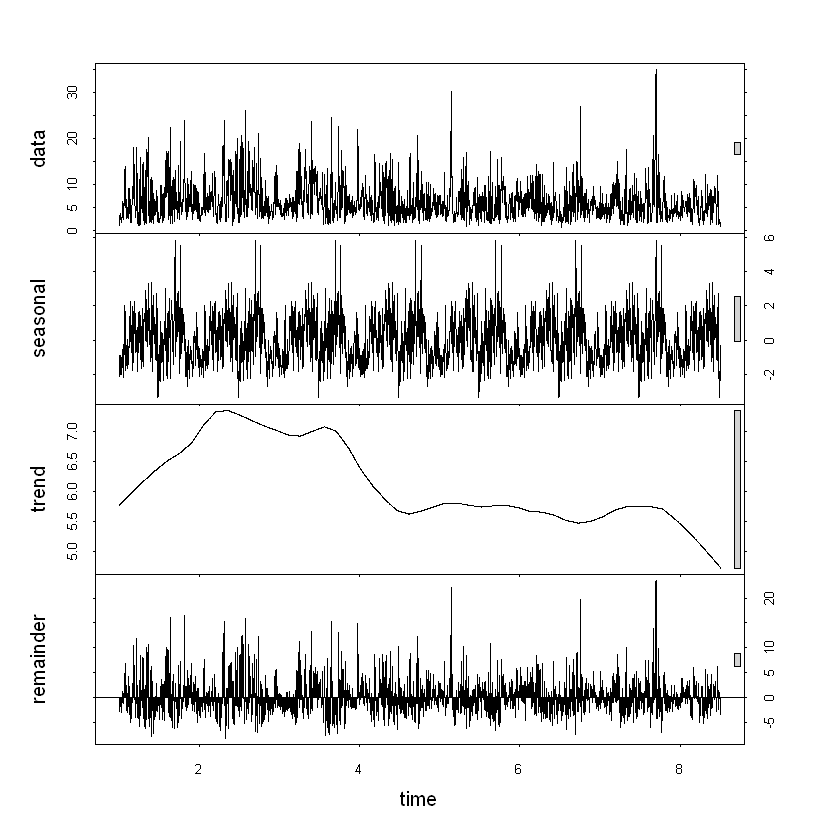

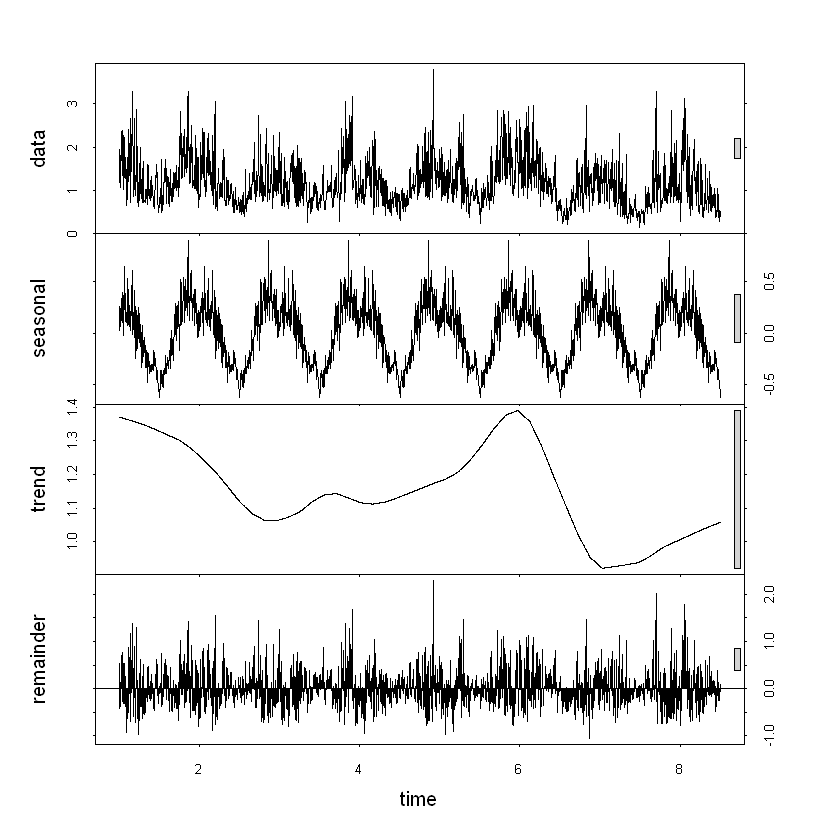

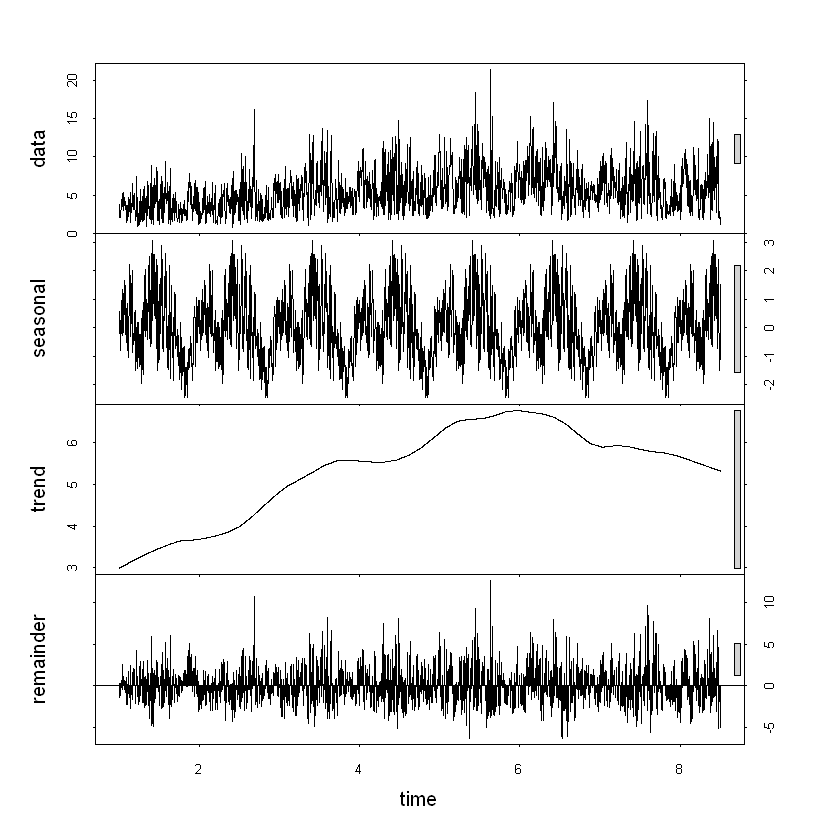

In [34]:
plot(stl(ts(data$feelsLikeTemperature_fixed, frequency = 365), s.window = "periodic"))

plot(stl(ts(data$absorbing_aerosol_index, frequency = 365), s.window = "periodic"))

plot(stl(ts(data$NO2, frequency = 365), s.window = "periodic"))

plot(stl(ts(data$pm2p5, frequency = 365), s.window = "periodic", na.action = na.omit))

plot(stl(ts(data$pans, frequency = 365), s.window = "periodic", na.action = na.omit))

plot(stl(ts(data$nmvoc, frequency = 365), s.window = "periodic", na.action = na.omit))

# Tendencijos

Warning message in data$trend[1:2772] <- as.numeric(decomp$time.series[, "trend"]):
"number of items to replace is not a multiple of replacement length"
Warning message:
"Removed 31 rows containing missing values or values outside the scale range
(`geom_line()`)."


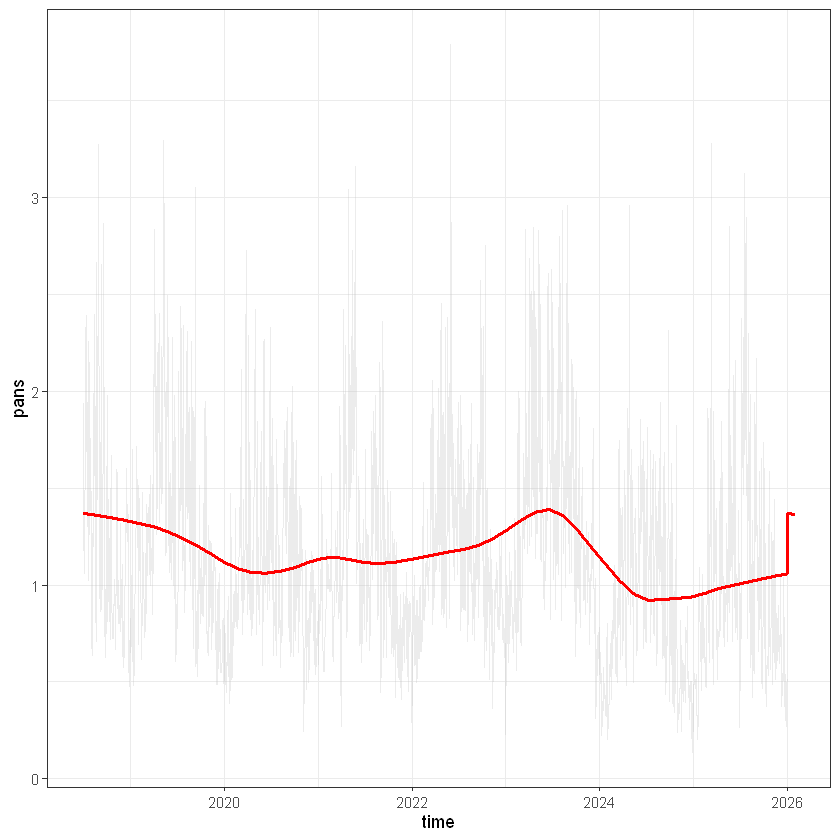

In [35]:
ts_data <- ts(data$pans, frequency = 365)

decomp <- stl(ts_data, s.window = "periodic", na.action = na.omit)

data$trend[1:2772] <- as.numeric(decomp$time.series[, "trend"])

data %>% 
  ggplot(aes(x = time)) +
  geom_line(aes(y = pans), alpha = 0.3, color = "gray") +
  geom_line(aes(y = trend), color = "red", linewidth = 1) +
  theme_bw()

Warning message in data$trend[1:2772] <- as.numeric(decomp$time.series[, "trend"]):
"number of items to replace is not a multiple of replacement length"
Warning message:
"Removed 31 rows containing missing values or values outside the scale range
(`geom_line()`)."


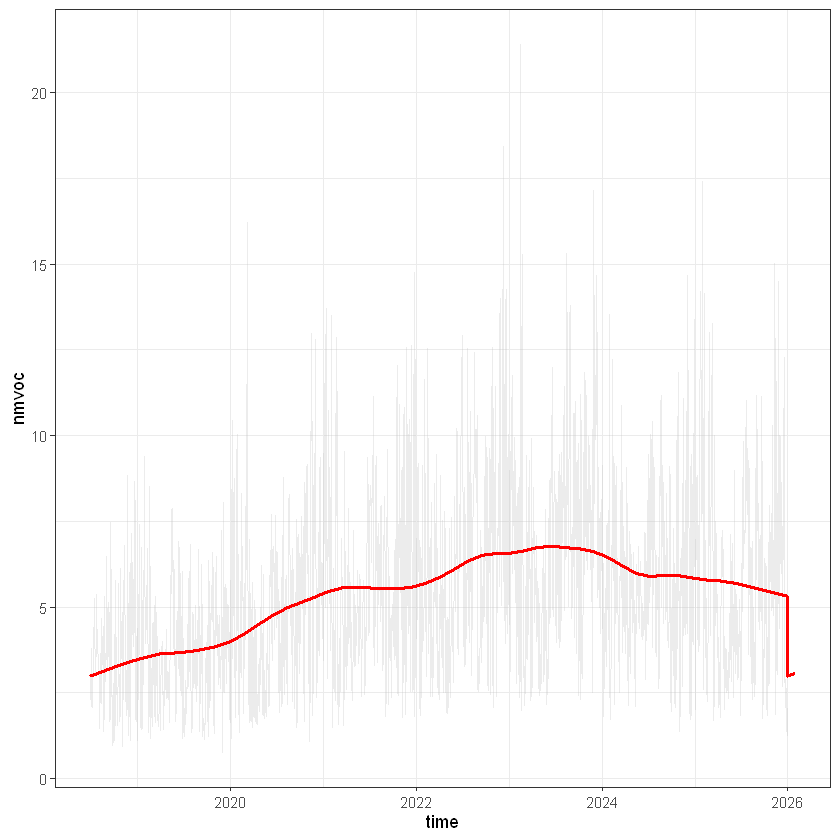

In [36]:
ts_data <- ts(data$nmvoc, frequency = 365)

decomp <- stl(ts_data, s.window = "periodic", na.action = na.omit)

data$trend[1:2772] <- as.numeric(decomp$time.series[, "trend"])

data %>% 
  ggplot(aes(x = time)) +
  geom_line(aes(y = nmvoc), alpha = 0.3, color = "gray") +
  geom_line(aes(y = trend), color = "red", linewidth = 1) +
  theme_bw()

Warning message in data$trend[1:2772] <- as.numeric(decomp$time.series[, "trend"]):
"number of items to replace is not a multiple of replacement length"
Warning message:
"Removed 31 rows containing missing values or values outside the scale range
(`geom_line()`)."


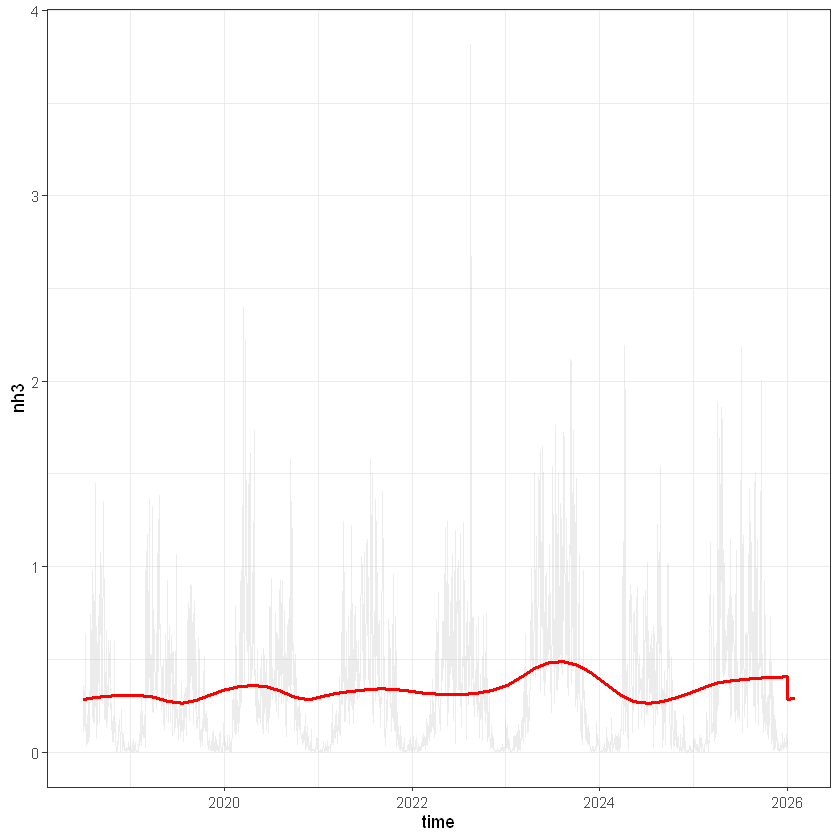

In [37]:
ts_data <- ts(data$nh3, frequency = 365)

decomp <- stl(ts_data, s.window = "periodic", na.action = na.omit)

data$trend[1:2772] <- as.numeric(decomp$time.series[, "trend"])

data %>% 
  ggplot(aes(x = time)) +
  geom_line(aes(y = nh3), alpha = 0.3, color = "gray") +
  geom_line(aes(y = trend), color = "red", linewidth = 1) +
  theme_bw()

# Meteo vs ECMWF

## Krituliai

Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_align()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


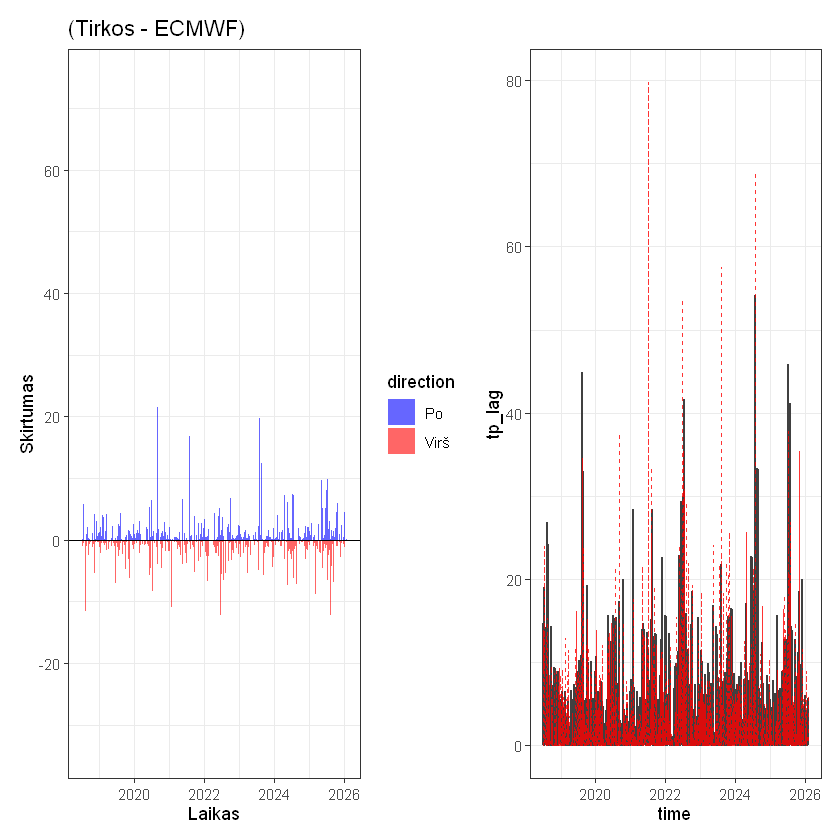

In [38]:
plot_data <- data %>%
  mutate(tp_lag = lag(tp, 1))

plot_data <- plot_data %>%
  mutate(
    diff = xgb_precipitation - tp_lag,
    direction = ifelse(diff >= 0, "Po", "Virš")
  )

p_tp_vs_tp1 <- ggplot(plot_data, aes(x = time, y = diff)) +
  geom_area(aes(fill = direction), alpha = 0.6) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
  scale_fill_manual(values = c("Virš" = "red", "Po" = "blue")) +
  theme_bw() +
  labs(title = "(Tirkos - ECMWF)", y = "Skirtumas", x = "Laikas")

p_tp_vs_tp2 <- ggplot(plot_data, aes(x=time, y=tp_lag)) +
  geom_line(aes(y = tp_lag), linewidth = 0.75, color = 'gray25') +
  geom_line(data = data, 
            aes(x=time, y=xgb_precipitation), 
            color='red', 
            alpha = 0.8, 
            linetype = 'dashed') +
  theme_bw()

p_tp_vs_tp1 + p_tp_vs_tp2